# WM-811K Wafer Map — Model 5: CNN overfitted on 9 class-average heatmaps

**Idea:** compute one class-average heatmap from **all** 172,950 labeled wafer maps,
giving exactly 9 prototype images (one per class). Train a CNN to **overfit** on
those 9 images — no train/val split, no dropout. Then evaluate on the entire labeled
dataset (all 172,950 maps become the test set).

This probes whether a CNN can learn a non-linear prototype-matching rule from
perfectly averaged templates and transfer it to real, noisy wafer maps — a harder
generalisation test than the KL-divergence baseline (Model 4).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Load the data

In [2]:
import pickle
import sys

# Patch old pandas module paths for compatibility (pickle was saved with pandas < 0.20)
_compat_map = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}

for old, new in _compat_map.items():
    try:
        sys.modules[old] = __import__(new, fromlist=[''])
    except ImportError:
        pass

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        for old, new in _compat_map.items():
            if module.startswith(old):
                module = module.replace(old, new, 1)
                break
        return super().find_class(module, name)

with open('./Data/LSWMD.pkl', 'rb') as f:
    try:
        df = pickle.load(f, encoding='latin1')
    except (ModuleNotFoundError, ImportError):
        f.seek(0)
        df = _CompatUnpickler(f)
        df.encoding = 'latin1'
        df = df.load()

print(f'Shape: {df.shape}')
df.head()

/tmp/ipykernel_21718/3958013367.py:30: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 2. Extract labels and filter out unknown failure types

In [3]:
def extract_label(x):
    if isinstance(x, (list, np.ndarray)):
        flat = np.array(x).flatten()
        if len(flat) > 0:
            return str(flat[0])
    if isinstance(x, str):
        return x
    return 'unknown'

df['failure_label'] = df['failureType'].apply(extract_label)
df_labeled = df[~df['failure_label'].isin(['unknown', ''])].reset_index(drop=True)

print(f'Before filter: {len(df):,}')
print(f'After filter:  {len(df_labeled):,}')
print('\nClass counts:')
print(df_labeled['failure_label'].value_counts())

Before filter: 811,457
After filter:  172,950

Class counts:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 3. Class index

In [4]:
classes = sorted(df_labeled['failure_label'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(f'{NUM_CLASSES} classes: {classes}')

df_labeled['label_idx'] = df_labeled['failure_label'].map(class_to_idx)
all_labels = df_labeled['label_idx'].values

9 classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


## 4. Build 9 class-average heatmaps

All 172,950 labeled wafer maps are resized to 64×64 (nearest-neighbor, preserving
the 0/1/2 codes). An incremental mean accumulates the sum per class without ever
holding the full resized array in memory.

In [5]:
IMG_SIZE = 64

def resize_wafer(wmap, target=IMG_SIZE):
    wmap = np.asarray(wmap)
    if wmap.ndim < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
        return np.zeros((target, target), dtype=np.float32)
    h, w = wmap.shape
    return zoom(wmap, (target / h, target / w), order=0).astype(np.float32)

heatmap_sum = np.zeros((NUM_CLASSES, IMG_SIZE, IMG_SIZE), dtype=np.float64)
heatmap_cnt = np.zeros(NUM_CLASSES, dtype=np.int64)

print('Computing class-average heatmaps (incremental pass over all labeled data)...')
for i, (wmap, c) in enumerate(zip(df_labeled['waferMap'].values, all_labels)):
    heatmap_sum[c] += resize_wafer(wmap)
    heatmap_cnt[c] += 1
    if (i + 1) % 20_000 == 0:
        print(f'  {i+1:,} / {len(df_labeled):,}')

heatmaps = (heatmap_sum / heatmap_cnt[:, None, None]).astype(np.float32)
print('Done.')
print(f'\nHeatmap value range: [{heatmaps.min():.4f}, {heatmaps.max():.4f}]  (codes are 0/1/2)')
for c in range(NUM_CLASSES):
    print(f'  {idx_to_class[c]:12s}: {heatmap_cnt[c]:,} maps')

Computing class-average heatmaps (incremental pass over all labeled data)...
  20,000 / 172,950
  40,000 / 172,950
  60,000 / 172,950
  80,000 / 172,950
  100,000 / 172,950
  120,000 / 172,950
  140,000 / 172,950
  160,000 / 172,950
Done.

Heatmap value range: [0.0000, 1.9799]  (codes are 0/1/2)
  Center      : 4,294 maps
  Donut       : 555 maps
  Edge-Loc    : 5,189 maps
  Edge-Ring   : 9,680 maps
  Loc         : 3,593 maps
  Near-full   : 149 maps
  Random      : 866 maps
  Scratch     : 1,193 maps
  none        : 147,431 maps


### Visualise the 9 prototypes and scale to [0, 1]

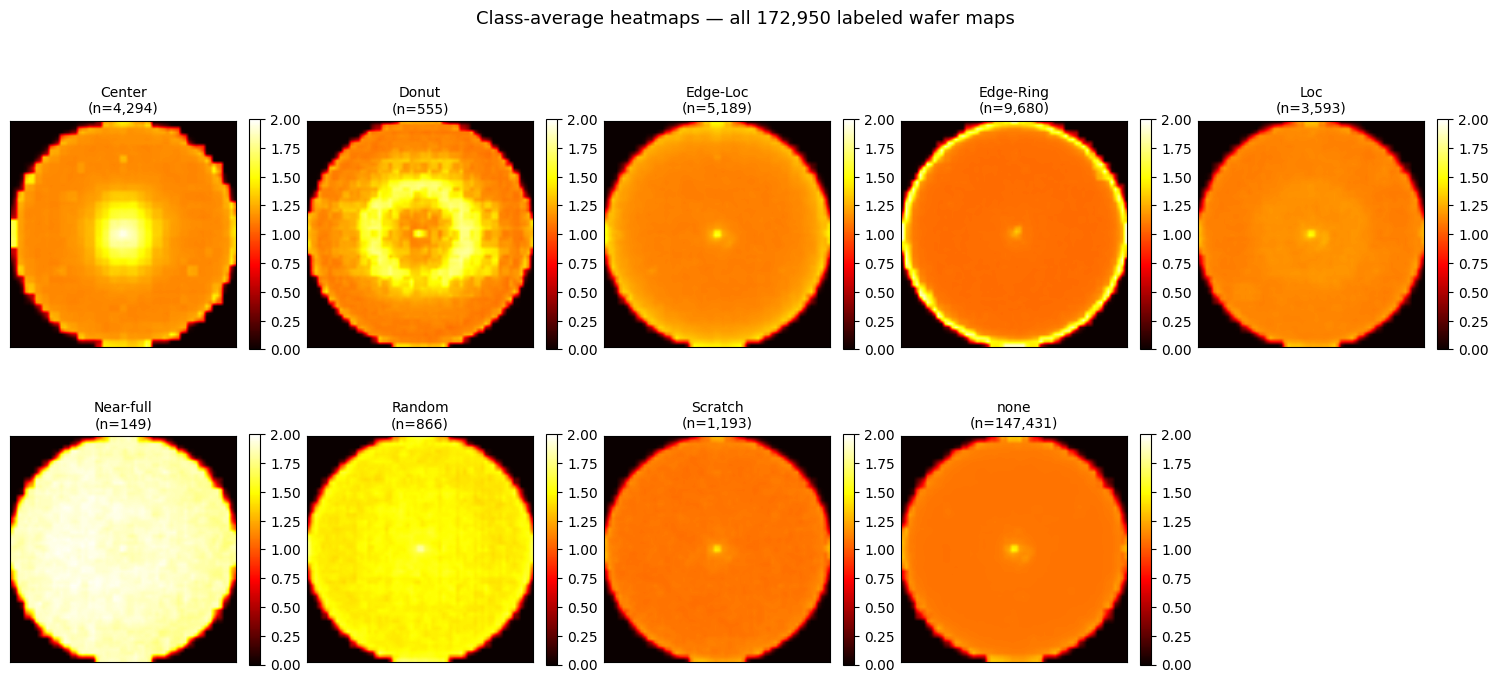

After /2 scaling: [0.0000, 0.9899]


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()
for c in range(NUM_CLASSES):
    im = axes[c].imshow(heatmaps[c], cmap='hot', vmin=0, vmax=2, interpolation='bilinear')
    axes[c].set_title(f'{idx_to_class[c]}\n(n={heatmap_cnt[c]:,})', fontsize=10)
    axes[c].set_xticks([]); axes[c].set_yticks([])
    plt.colorbar(im, ax=axes[c], fraction=0.046)
for j in range(NUM_CLASSES, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Class-average heatmaps — all 172,950 labeled wafer maps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Divide by 2 → [0, 1], same normalisation as WaferMapDataset in model1
heatmaps_01 = heatmaps / 2.0
print(f'After /2 scaling: [{heatmaps_01.min():.4f}, {heatmaps_01.max():.4f}]')

## 5. Datasets

* **Training set** — `HeatmapDataset`: 9 samples, one per class, already scaled.
* **Test set** — `WaferMapDataset`: all 172,950 labeled maps, resized on-the-fly.

In [7]:
class HeatmapDataset(Dataset):
    """9-sample training set: one class-average prototype per class."""
    def __init__(self, heatmaps_01):
        self.x = torch.from_numpy(heatmaps_01).unsqueeze(1).float()  # (9, 1, H, W)
        self.y = torch.arange(len(heatmaps_01), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i]


class WaferMapDataset(Dataset):
    """All labeled wafer maps; resize on-the-fly and scale to [0, 1]."""
    def __init__(self, df, img_size=IMG_SIZE):
        self.maps   = df['waferMap'].values
        self.labels = df['label_idx'].values.astype(np.int64)
        self.img_size = img_size

    def __len__(self):
        return len(self.labels)

    def _resize(self, wmap):
        wmap = np.asarray(wmap)
        if wmap.ndim < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
            return np.zeros((self.img_size, self.img_size), dtype=np.float32)
        h, w = wmap.shape
        return zoom(wmap, (self.img_size / h, self.img_size / w), order=0)

    def __getitem__(self, i):
        wmap = self._resize(self.maps[i]).astype(np.float32) / 2.0  # 0/1/2 → [0, 1]
        x = torch.from_numpy(wmap).unsqueeze(0)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y


train_ds = HeatmapDataset(heatmaps_01)
test_ds  = WaferMapDataset(df_labeled)

print(f'train_ds (prototypes): {len(train_ds)} samples')
print(f'test_ds  (all labeled): {len(test_ds):,} samples')

x0, y0 = train_ds[0]
print(f'\nprototype x: shape={tuple(x0.shape)}  min={x0.min():.4f}  max={x0.max():.4f}')
print(f'prototype y: {y0.item()} → {idx_to_class[y0.item()]}')

train_ds (prototypes): 9 samples
test_ds  (all labeled): 172,950 samples

prototype x: shape=(1, 64, 64)  min=0.0000  max=0.9813
prototype y: 0 → Center


## 6. DataLoader (test only — training runs as a single full batch)

In [8]:
BATCH_SIZE_TEST = 256
NUM_WORKERS = 0

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_TEST, shuffle=False,
                         num_workers=NUM_WORKERS)

print(f'test_loader: {len(test_loader)} batches of up to {BATCH_SIZE_TEST}')

test_loader: 676 batches of up to 256


## 7. Model 5 — same CNN as Model 1, Dropout and BatchNorm removed

Dropout is the primary regulariser in Model 1; removing it lets the network freely
memorise the 9 prototypes.

BatchNorm must also be removed: with only 9 training images the running mean/variance
it accumulates is computed from 9 prototype images only. At test time (`eval` mode)
those wrong running stats are applied to the 172 k real wafer maps, shifting activations
so far off-distribution that the model's decision boundaries collapse. Without BatchNorm
the network uses raw activations consistently in both train and test mode.

In [9]:
class Model5(nn.Module):
    def __init__(self, num_classes: int = 9, in_channels: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=6, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=6, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=6, padding=1)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2)

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 64, 64)
            dummy = self.pool3(self.relu3(self.conv3(
                     self.pool2(self.relu2(self.conv2(
                     self.pool1(self.relu1(self.conv1(dummy)))))))))
            flat_size = dummy.numel()

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(flat_size, 256)
        self.relu4   = nn.ReLU(inplace=True)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x


# GTX 1080 Ti is sm_61; this PyTorch build requires sm_70+. CUDA errors are
# asynchronous so a runtime probe corrupts the CUDA context for the whole process.
device = 'cpu'
print(f'device: {device}')

_probe = Model5(num_classes=NUM_CLASSES)
print(f'Model5 parameters: {sum(p.numel() for p in _probe.parameters()):,}')
del _probe

device: cpu
Model5 parameters: 1,191,785


## 8. Train to overfit on 9 prototypes

The entire training set fits in one batch (9 samples), so each epoch is one full-batch
gradient step. We stop when training accuracy reaches 1.0 and loss drops below 1e-4,
or after 2000 epochs.

In [10]:
import time

MAX_EPOCHS = 2000
LR = 1e-3

model5    = Model5(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model5.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Move the 9 prototypes to device once
X_proto = train_ds.x.to(device)   # (9, 1, 64, 64)
y_proto = train_ds.y.to(device)   # (9,)

with torch.no_grad():
    logits = model5(X_proto)
print(f'forward output: {tuple(logits.shape)}  (expected (9, {NUM_CLASSES}))')

history = {'loss': [], 'acc': []}
t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    model5.train()
    logits = model5(X_proto)
    loss   = criterion(logits, y_proto)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc = (logits.argmax(1) == y_proto).float().mean().item()
    history['loss'].append(loss.item())
    history['acc'].append(acc)

    if epoch % 100 == 0 or epoch == 1:
        print(f'epoch {epoch:4d} | loss {loss.item():.6f} | train acc {acc:.4f}')

    if acc == 1.0 and loss.item() < 1e-4:
        print(f'\nConverged at epoch {epoch} — loss={loss.item():.2e}  acc={acc:.4f}')
        break

print(f'\nTotal training time: {time.time() - t0:.1f}s')
print(f'Final: loss={history["loss"][-1]:.6f}  train acc={history["acc"][-1]:.4f}')

forward output: (9, 9)  (expected (9, 9))
epoch    1 | loss 2.197242 | train acc 0.1111
epoch  100 | loss 0.130998 | train acc 1.0000
epoch  200 | loss 0.117317 | train acc 1.0000
epoch  300 | loss 0.003493 | train acc 1.0000
epoch  400 | loss 0.000469 | train acc 1.0000
epoch  500 | loss 0.000185 | train acc 1.0000
epoch  600 | loss 0.000116 | train acc 1.0000

Converged at epoch 638 — loss=1.00e-04  acc=1.0000

Total training time: 3.3s
Final: loss=0.000100  train acc=1.0000


### Training curve

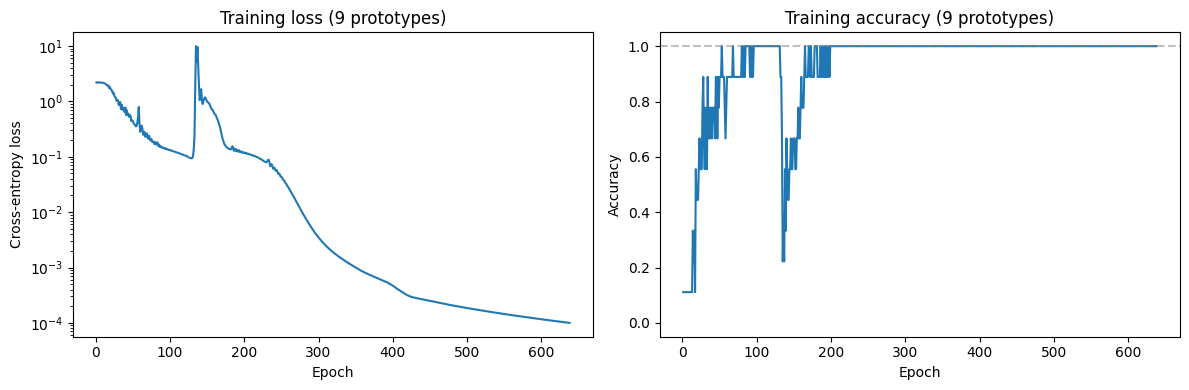

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history['loss']) + 1)

ax1.plot(epochs, history['loss'])
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training loss (9 prototypes)')
ax1.set_yscale('log')

ax2.plot(epochs, history['acc'])
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training accuracy (9 prototypes)')
ax2.set_ylim(-0.05, 1.05)
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Evaluate on all 172,950 labeled wafer maps

In [12]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, cohen_kappa_score,
)


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        ps.append(model(xb).argmax(1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)


y_true, y_pred = collect_predictions(model5, test_loader)
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'Test samples: {len(y_true):,}  (all labeled wafer maps)')
print(f'\nAccuracy:           {accuracy_score(y_true, y_pred):.4f}')
print(f'Balanced accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}  (mean per-class recall)')
print(f"Cohen's kappa:      {cohen_kappa_score(y_true, y_pred):.4f}")
for avg in ('macro', 'weighted'):
    p = precision_score(y_true, y_pred, average=avg, zero_division=0)
    r = recall_score(   y_true, y_pred, average=avg, zero_division=0)
    f = f1_score(       y_true, y_pred, average=avg, zero_division=0)
    print(f'{avg:>8s}: precision {p:.4f}  recall {r:.4f}  f1 {f:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=target_names,
                            digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print('Confusion matrix (rows=true, cols=predicted):')
cm_df

Test samples: 172,950  (all labeled wafer maps)

Accuracy:           0.0802
Balanced accuracy:  0.4502  (mean per-class recall)
Cohen's kappa:      0.0461
   macro: precision 0.2802  recall 0.4502  f1 0.1869
weighted: precision 0.8656  recall 0.0802  f1 0.0867

Per-class report:
              precision    recall  f1-score   support

      Center     0.3024    0.5629    0.3934      4294
       Donut     0.0212    0.8559    0.0414       555
    Edge-Loc     0.0550    0.3640    0.0955      5189
   Edge-Ring     0.8354    0.4110    0.5509      9680
         Loc     0.0110    0.1411    0.0205      3593
   Near-full     0.3180    0.9262    0.4734       149
      Random     0.0195    0.4896    0.0375       866
     Scratch     0.0105    0.2758    0.0202      1193
        none     0.9490    0.0252    0.0491    147431

    accuracy                         0.0802    172950
   macro avg     0.2802    0.4502    0.1869    172950
weighted avg     0.8656    0.0802    0.0867    172950

Confusion matri

,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
Center,2417,1066,13,0,569,35,131,5,58
Donut,15,475,17,0,3,40,3,2,0
Edge-Loc,69,434,1889,158,716,50,1182,644,47
Edge-Ring,58,34,3281,3978,318,0,761,1225,25
Loc,286,1072,505,153,507,21,452,559,38
Near-full,0,0,0,0,0,138,11,0,0
Random,2,298,7,0,4,131,424,0,0
Scratch,56,201,210,5,252,3,105,329,32
none,5091,18829,28433,468,43539,16,18659,28677,3719
